# Сбор результатов

Ноутбук собирает сильные и понятные серии экспериментов, строит общие таблицы и сохраняет графики.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

root = Path('.')
if not (root / 'pinn_model.py').exists():
    for p in [Path('../..'), Path('../../..'), Path('..')]:
        if (p / 'pinn_model.py').exists():
            root = p
            break

base_dir = root / 'final' / 'final 2'
out_dir = base_dir / 'results_outputs'
fig_dir = out_dir / 'figures'
table_dir = out_dir / 'tables'
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

print('root:', root.resolve())
print('out_dir:', out_dir.resolve())

root: /Users/leonidtikhanov/Projects/PINN_course_work
out_dir: /Users/leonidtikhanov/Projects/PINN_course_work/final/final 2/results_outputs


In [16]:
files = [
    ('heat1d_precision', 'results_exp_1_heat1d_precision/exp_1_heat1d_precision_summary.csv'),
    ('burgers_long_lbfgs', 'results_exp_11_burgers1d_short_adam_long_lbfgs/results_exp_11_burgers1d_short_adam_long_lbfgs/exp_11_burgers1d_short_adam_long_lbfgs_summary.csv'),
    ('helmholtz_resample_sweep', 'results_exp_6_helmholtz1d_resampling_final/exp_6_helmholtz1d_resampling_final_summary.csv'),
    ('helmholtz_large_lbfgs', 'results_exp_9_helmholtz1d_large_lbfgs/results_exp_9_helmholtz1d_large_lbfgs/exp_9_helmholtz1d_large_lbfgs_summary.csv'),
    ('helmholtz_inner10', 'results_exp_16_helmholtz1d_exploded_inner10/results_exp_16_helmholtz1d_exploded_inner10/exp_16_helmholtz1d_exploded_inner10_summary.csv'),
    ('final_results', 'final/final 2/final_summary.csv'),
]

arr = []
for name, rel in files:
    p = root / rel
    if not p.exists():
        print('missing:', rel)
        continue
    df = pd.read_csv(p)
    df['source'] = name
    if 'variant' not in df.columns:
        df['variant'] = name
    if 'best_l2_error' not in df.columns:
        df['best_l2_error'] = df['final_l2_error']
    if 'elapsed_time' not in df.columns:
        if 'time_sec' in df.columns:
            df['elapsed_time'] = df['time_sec']
        else:
            df['elapsed_time'] = np.nan
    if 'adam_steps_config' in df.columns and 'adam_steps' not in df.columns:
        df['adam_steps'] = df['adam_steps_config']
    if 'lbfgs_steps_config' in df.columns and 'lbfgs_steps' not in df.columns:
        df['lbfgs_steps'] = df['lbfgs_steps_config']
    if 'case_name' not in df.columns:
        df['case_name'] = ''
    else:
        df['case_name'] = df['case_name'].astype('object')
    if 'case_value' not in df.columns:
        df['case_value'] = np.nan
    for col in ['nu', 'm', 'beta', 'alpha']:
        if col in df.columns:
            mask = df['case_value'].isna() & df[col].notna()
            df.loc[mask, 'case_name'] = col
            df.loc[mask, 'case_value'] = df.loc[mask, col]
    mask = df['case_value'].isna()
    df.loc[mask, 'case_name'] = 'base'
    df.loc[mask, 'case_value'] = 0.0
    arr.append(df)

runs = pd.concat(arr, ignore_index=True)
runs = runs[runs['dtype'].isin(['fp32', 'fp64', 'fp16'])].copy()
runs['best_l2_error'] = pd.to_numeric(runs['best_l2_error'], errors='coerce')
runs['final_l2_error'] = pd.to_numeric(runs['final_l2_error'], errors='coerce')
runs['case_value'] = pd.to_numeric(runs['case_value'], errors='coerce')
runs['elapsed_time'] = pd.to_numeric(runs['elapsed_time'], errors='coerce')
runs.to_csv(table_dir / 'all_loaded_runs.csv', index=False)

print(runs.shape)
display(runs[['source', 'task_name', 'variant', 'case_name', 'case_value', 'dtype', 'seed', 'best_l2_error', 'final_l2_error']].head(20))

(109, 48)


/var/folders/ws/03sf1dmx4wbg1vvmvxb0x00w0000gn/T/ipykernel_17640/2337224108.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'case_value'] = df.loc[mask, col]
/var/folders/ws/03sf1dmx4wbg1vvmvxb0x00w0000gn/T/ipykernel_17640/2337224108.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'case_value'] = df.loc[mask, col]
/var/folders/ws/03sf1dmx4wbg1vvmvxb0x00w0000gn/T/ipykernel_17640/2337224108.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible 

,source,task_name,variant,case_name,case_value,dtype,seed,best_l2_error,final_l2_error
0,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,fp32,0,0.000375,0.000375
1,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,fp32,1,0.000217,0.000217
2,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,fp32,2,0.000599,0.000599
3,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,fp64,0,0.000830,0.000830
4,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,fp64,1,0.000311,0.000311
5,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,fp64,2,0.000277,0.000277
6,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.001,fp32,0,0.270881,0.270881
7,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.001,fp64,0,0.099582,0.100316
8,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.002,fp32,0,0.047775,0.050615
9,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.002,fp64,0,0.048379,0.050917


In [17]:
main = runs[(runs['dtype'].isin(['fp32', 'fp64'])) & runs['best_l2_error'].notna()].copy()

cols = ['source', 'task_name', 'variant', 'case_name', 'case_value', 'dtype']
grouped = main.groupby(cols, dropna=False).agg(
    best_l2_mean=('best_l2_error', 'mean'),
    best_l2_std=('best_l2_error', 'std'),
    best_l2_min=('best_l2_error', 'min'),
    best_l2_max=('best_l2_error', 'max'),
    final_l2_mean=('final_l2_error', 'mean'),
    elapsed_time_mean=('elapsed_time', 'mean'),
    count=('best_l2_error', 'count'),
).reset_index()

grouped.to_csv(table_dir / 'grouped_results.csv', index=False)
display(grouped.sort_values(['task_name', 'source', 'case_value', 'dtype']).head(30))

,source,task_name,variant,case_name,case_value,dtype,best_l2_mean,best_l2_std,best_l2_min,best_l2_max,final_l2_mean,elapsed_time_mean,count
0,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.001,fp32,0.270881,NaN,0.270881,0.270881,0.270881,690.630381,1
1,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.001,fp64,0.099582,NaN,0.099582,0.099582,0.100316,5103.282607,1
2,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.002,fp32,0.047775,NaN,0.047775,0.047775,0.050615,697.438390,1
3,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.002,fp64,0.048379,NaN,0.048379,0.048379,0.050917,5115.536488,1
4,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.005,fp32,0.047802,NaN,0.047802,0.047802,0.052022,694.507225,1
5,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.005,fp64,0.051908,NaN,0.051908,0.051908,0.052059,5001.841320,1
6,final_results,burgers1d,burgers_more_points,nu,0.001,fp32,0.094845,0.076464,0.040777,0.148914,0.096199,502.503982,2
7,final_results,burgers1d,burgers_more_points,nu,0.001,fp64,0.169969,0.009588,0.163189,0.176749,0.172000,663.735171,2
8,final_results,burgers1d,burgers_more_points,nu,0.002,fp32,0.048779,0.002231,0.047201,0.050356,0.050466,467.524262,2
9,final_results,burgers1d,burgers_more_points,nu,0.002,fp64,0.046524,0.000335,0.046287,0.046760,0.050467,670.501160,2


In [18]:
idx = ['source', 'task_name', 'variant', 'case_name', 'case_value']
piv = grouped.pivot_table(index=idx, columns='dtype', values=['best_l2_mean', 'final_l2_mean', 'elapsed_time_mean', 'count'], aggfunc='first')
piv.columns = [a + '_' + b for a, b in piv.columns]
piv = piv.reset_index()

piv['fp64_over_fp32_best'] = piv['best_l2_mean_fp64'] / piv['best_l2_mean_fp32']
piv['fp64_over_fp32_final'] = piv['final_l2_mean_fp64'] / piv['final_l2_mean_fp32']
piv['result'] = 'similar'
piv.loc[piv['fp64_over_fp32_best'] < 0.7, 'result'] = 'fp64 better'
piv.loc[piv['fp64_over_fp32_best'] > 1.3, 'result'] = 'fp32 better'

piv = piv.sort_values(['task_name', 'source', 'case_value', 'variant'])
piv.to_csv(table_dir / 'fp64_ratio_all.csv', index=False)
display(piv)

,source,task_name,variant,case_name,case_value,best_l2_mean_fp32,best_l2_mean_fp64,count_fp32,count_fp64,elapsed_time_mean_fp32,elapsed_time_mean_fp64,final_l2_mean_fp32,final_l2_mean_fp64,fp64_over_fp32_best,fp64_over_fp32_final,result
0,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.001,0.270881,0.099582,1,1,690.630381,5103.282607,0.270881,0.100316,0.367622,0.370330,fp64 better
1,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.002,0.047775,0.048379,1,1,697.438390,5115.536488,0.050615,0.050917,1.012650,1.005981,similar
2,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.005,0.047802,0.051908,1,1,694.507225,5001.841320,0.052022,0.052059,1.085893,1.000710,similar
3,final_results,burgers1d,burgers_more_points,nu,0.001,0.094845,0.169969,2,2,502.503982,663.735171,0.096199,0.172000,1.792065,1.787958,fp32 better
4,final_results,burgers1d,burgers_more_points,nu,0.002,0.048779,0.046524,2,2,467.524262,670.501160,0.050466,0.050467,0.953769,1.000028,similar
5,final_results,convection1d,convection_beta30_lbfgs_grid,beta,30.000,0.010941,0.006625,2,2,473.154110,450.424339,0.010941,0.006710,0.605541,0.613321,fp64 better
6,final_results,convection1d,convection_beta50_wide_lbfgs,beta,50.000,0.687307,0.007182,1,1,1088.638228,2370.150009,0.687307,0.007182,0.010449,0.010449,fp64 better
9,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,0.000397,0.000473,3,3,89.411730,164.385233,0.000397,0.000473,1.190742,1.190742,similar
7,final_results,helmholtz1d,helmholtz_resample_long,m,8.000,0.003250,0.115449,2,2,131.208901,124.947947,0.003250,0.115450,35.524190,35.524226,fp32 better
8,final_results,helmholtz1d,helmholtz_resample_long,m,12.000,0.012531,0.002114,2,2,141.179654,141.011743,0.012531,0.002548,0.168675,0.203348,fp64 better


In [19]:
selected_specs = [
    ('final_results', 'convection1d', 'convection_beta30_lbfgs_grid', 'beta', 30.0),
    ('final_results', 'convection1d', 'convection_beta50_wide_lbfgs', 'beta', 50.0),
    ('final_results', 'helmholtz1d', 'helmholtz_resample_long', 'm', 8.0),
    ('final_results', 'helmholtz1d', 'helmholtz_resample_long', 'm', 12.0),

    ('helmholtz_large_lbfgs', 'helmholtz1d', 'resample_proven_128', 'm', 8.0),
    ('helmholtz_large_lbfgs', 'helmholtz1d', 'resample_proven_128', 'm', 12.0),

    ('helmholtz_resample_sweep', 'helmholtz1d', 'helmholtz_resample_sweep', 'm', 7.0),
    ('helmholtz_resample_sweep', 'helmholtz1d', 'helmholtz_resample_sweep', 'm', 8.0),
    ('helmholtz_resample_sweep', 'helmholtz1d', 'helmholtz_resample_sweep', 'm', 9.0),
    ('helmholtz_resample_sweep', 'helmholtz1d', 'helmholtz_resample_sweep', 'm', 10.0),
    ('helmholtz_resample_sweep', 'helmholtz1d', 'helmholtz_resample_sweep', 'm', 11.0),
    ('helmholtz_resample_sweep', 'helmholtz1d', 'helmholtz_resample_sweep', 'm', 12.0),

    ('helmholtz_inner10', 'helmholtz1d', 'width192_adam5e4_lbfgs1_steps1000_inner10_resample250', 'm', 10.0),
    ('helmholtz_inner10', 'helmholtz1d', 'width192_adam2e4_lbfgs1_steps1000_inner10_resample250', 'm', 10.0),
    ('helmholtz_inner10', 'helmholtz1d', 'width128_adam5e4_lbfgs05_steps1000_inner10_resample250', 'm', 12.0),
    ('helmholtz_inner10', 'helmholtz1d', 'width128_adam5e4_lbfgs1_steps1000_inner10_resample250', 'm', 12.0),
    ('helmholtz_inner10', 'helmholtz1d', 'width128_adam1e4_lbfgs1_steps1000_inner10_resample250', 'm', 12.0),

    ('heat1d_precision', 'heat1d', 'heat1d_precision', 'alpha', 0.1),
    ('final_results', 'burgers1d', 'burgers_more_points', 'nu', 0.002),
    ('burgers_long_lbfgs', 'burgers1d', 'adam3000_lbfgs5000_inner5_resample200', 'nu', 0.002),
    ('burgers_long_lbfgs', 'burgers1d', 'adam3000_lbfgs5000_inner5_resample200', 'nu', 0.005),
]

spec = pd.DataFrame(selected_specs, columns=['source', 'task_name', 'variant', 'case_name', 'case_value'])
selected = piv.merge(spec, on=['source', 'task_name', 'variant', 'case_name', 'case_value'], how='inner')

selected['fp32_learned'] = selected['best_l2_mean_fp32'] <= 0.05
selected['used_in_main'] = selected['fp32_learned']

selected_bad = selected[~selected['used_in_main']].copy()
selected_good = selected[selected['used_in_main']].copy()

selected_good['label'] = selected_good['task_name'] + ' ' + selected_good['case_name'] + '=' + selected_good['case_value'].astype(str) + ' | ' + selected_good['source']
selected_bad['label'] = selected_bad['task_name'] + ' ' + selected_bad['case_name'] + '=' + selected_bad['case_value'].astype(str) + ' | ' + selected_bad['source']

selected_good = selected_good.sort_values(['task_name', 'case_name', 'case_value', 'source', 'variant'])
selected_bad = selected_bad.sort_values(['task_name', 'case_name', 'case_value', 'source', 'variant'])

selected.to_csv(table_dir / 'selected_experiment_plan.csv', index=False)
selected_good.to_csv(table_dir / 'selected_comparisons.csv', index=False)
selected_bad.to_csv(table_dir / 'excluded_fp32_not_learned.csv', index=False)
old_bad = table_dir / 'excluded_unstable_cases.csv'
if old_bad.exists():
    old_bad.unlink()

old = table_dir / 'clear_fp64_results.csv'
if old.exists():
    old.unlink()

controls = selected_good[selected_good['task_name'].isin(['heat1d', 'burgers1d'])].copy()
controls.to_csv(table_dir / 'control_results.csv', index=False)

fp16 = runs[runs['dtype'] == 'fp16'].copy()
fp16.to_csv(table_dir / 'fp16_results.csv', index=False)

clear = selected_good.copy()
display(clear[['source', 'task_name', 'variant', 'case_name', 'case_value', 'best_l2_mean_fp32', 'best_l2_mean_fp64', 'fp64_over_fp32_best', 'result']])

display(selected_bad[['source', 'task_name', 'variant', 'case_name', 'case_value', 'best_l2_mean_fp32', 'best_l2_mean_fp64', 'fp64_over_fp32_best', 'result']])

,source,task_name,variant,case_name,case_value,best_l2_mean_fp32,best_l2_mean_fp64,fp64_over_fp32_best,result
0,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.002,0.047775,0.048379,1.012650,similar
2,final_results,burgers1d,burgers_more_points,nu,0.002,0.048779,0.046524,0.953769,similar
1,burgers_long_lbfgs,burgers1d,adam3000_lbfgs5000_inner5_resample200,nu,0.005,0.047802,0.051908,1.085893,similar
3,final_results,convection1d,convection_beta30_lbfgs_grid,beta,30.000,0.010941,0.006625,0.605541,fp64 better
5,heat1d_precision,heat1d,heat1d_precision,alpha,0.100,0.000397,0.000473,1.190742,similar
15,helmholtz_resample_sweep,helmholtz1d,helmholtz_resample_sweep,m,7.000,0.001348,0.000514,0.381523,fp64 better
6,final_results,helmholtz1d,helmholtz_resample_long,m,8.000,0.003250,0.115449,35.524190,fp32 better
13,helmholtz_large_lbfgs,helmholtz1d,resample_proven_128,m,8.000,0.002232,0.001076,0.481947,fp64 better
16,helmholtz_resample_sweep,helmholtz1d,helmholtz_resample_sweep,m,8.000,0.002536,0.001039,0.409678,fp64 better
17,helmholtz_resample_sweep,helmholtz1d,helmholtz_resample_sweep,m,9.000,0.001059,0.000926,0.873656,similar


,source,task_name,variant,case_name,case_value,best_l2_mean_fp32,best_l2_mean_fp64,fp64_over_fp32_best,result
4,final_results,convection1d,convection_beta50_wide_lbfgs,beta,50.0,0.687307,0.007182,0.010449,fp64 better


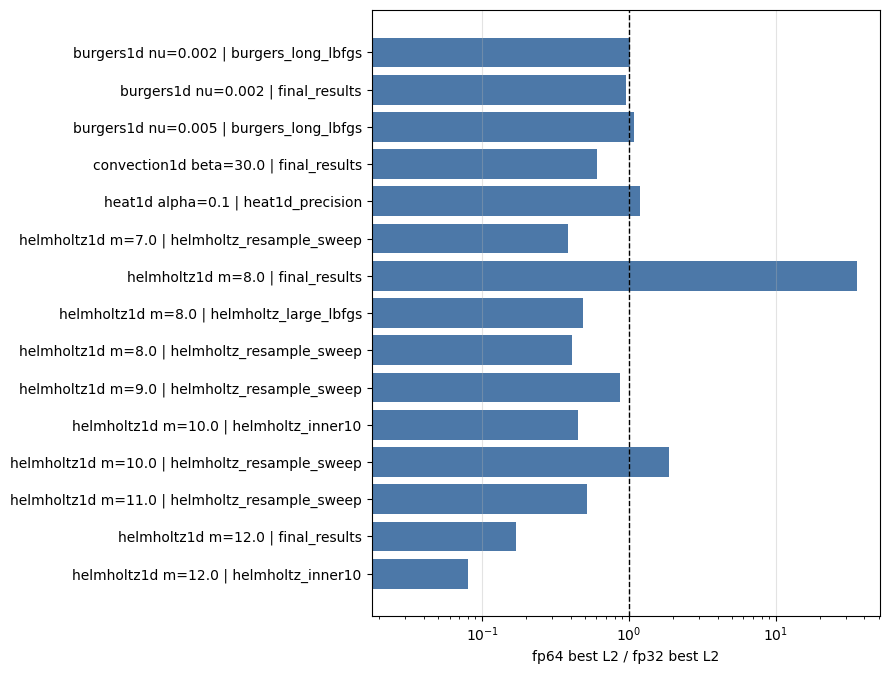

In [20]:
plot_df = clear.copy()
plot_df = plot_df.head(18).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, max(4, 0.38 * len(plot_df))))
ax.barh(plot_df['label'], plot_df['fp64_over_fp32_best'], color='#4c78a8')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('fp64 best L2 / fp32 best L2')
ax.grid(True, axis='x', alpha=0.35)
fig.tight_layout()
fig.savefig(fig_dir / 'fp64_ratio_selected.png', dpi=180)
plt.show()

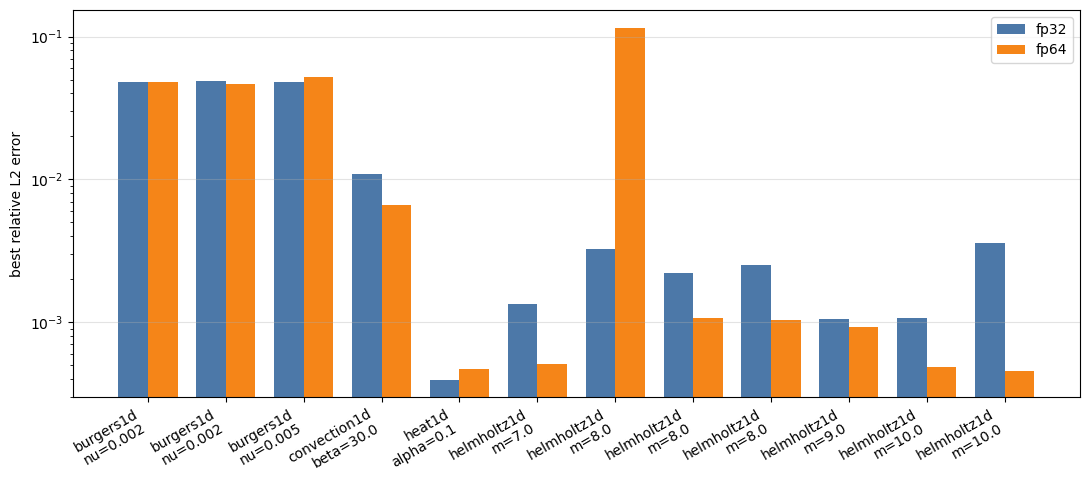

In [21]:
plot_df = clear.head(12).copy()
plot_df['short'] = plot_df['task_name'] + '\n' + plot_df['case_name'] + '=' + plot_df['case_value'].astype(str)

x = np.arange(len(plot_df))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w / 2, plot_df['best_l2_mean_fp32'], width=w, label='fp32', color='#4c78a8')
ax.bar(x + w / 2, plot_df['best_l2_mean_fp64'], width=w, label='fp64', color='#f58518')
ax.set_yscale('log')
ax.set_ylabel('best relative L2 error')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['short'], rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.35)
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / 'selected_best_l2.png', dpi=180)
plt.show()

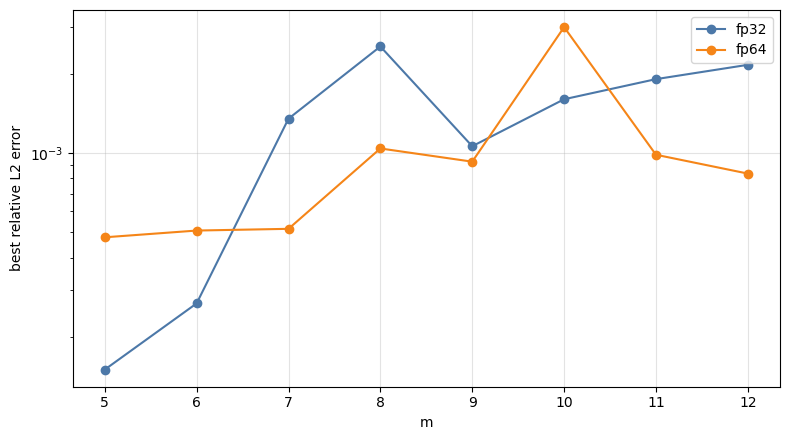

In [22]:
h = grouped[(grouped['source'] == 'helmholtz_resample_sweep') & (grouped['task_name'] == 'helmholtz1d')].copy()
h = h[h['case_value'].between(5, 12)]

fig, ax = plt.subplots(figsize=(8, 4.5))
for dtype, color in [('fp32', '#4c78a8'), ('fp64', '#f58518')]:
    cur = h[h['dtype'] == dtype].sort_values('case_value')
    ax.plot(cur['case_value'], cur['best_l2_mean'], marker='o', label=dtype, color=color)
ax.set_yscale('log')
ax.set_xlabel('m')
ax.set_ylabel('best relative L2 error')
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / 'helmholtz_resample_sweep.png', dpi=180)
plt.show()

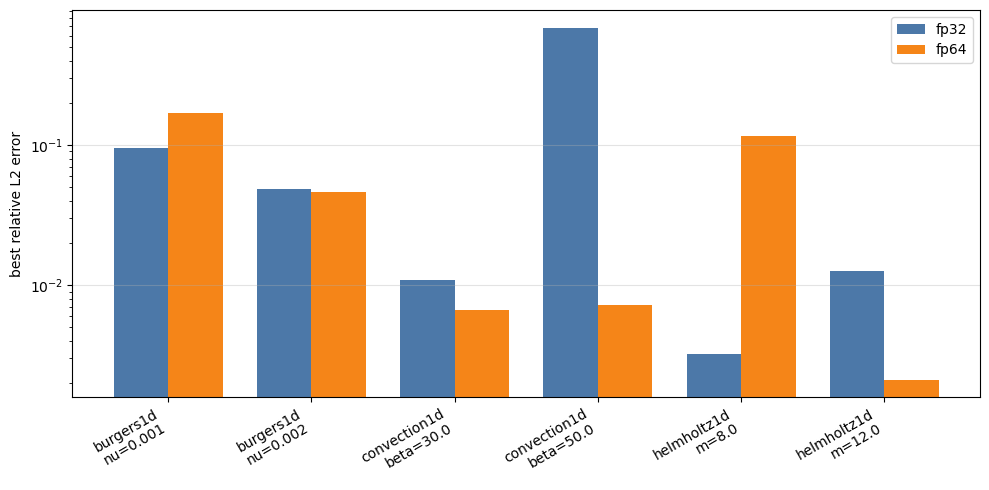

In [23]:
f = piv[piv['source'] == 'final_results'].copy()
f = f[f['task_name'].isin(['burgers1d', 'helmholtz1d', 'convection1d'])]
f['label'] = f['task_name'] + '\n' + f['case_name'] + '=' + f['case_value'].astype(str)

x = np.arange(len(f))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, f['best_l2_mean_fp32'], width=w, label='fp32', color='#4c78a8')
ax.bar(x + w / 2, f['best_l2_mean_fp64'], width=w, label='fp64', color='#f58518')
ax.set_yscale('log')
ax.set_ylabel('best relative L2 error')
ax.set_xticks(x)
ax.set_xticklabels(f['label'], rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.35)
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / 'final_results_cases.png', dpi=180)
plt.show()

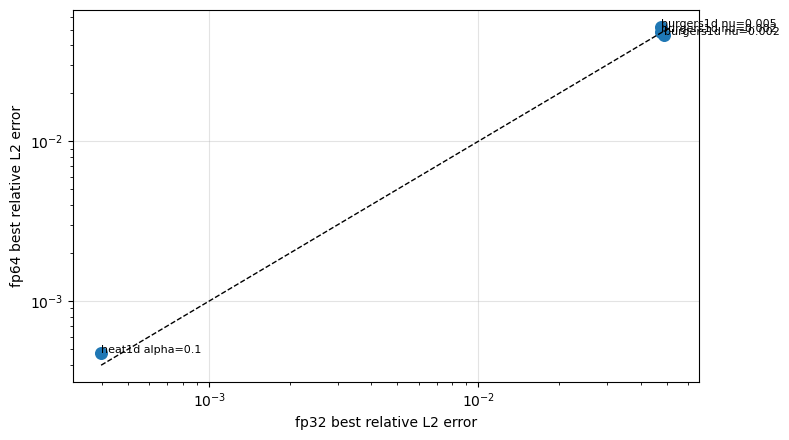

In [24]:
ctrl = controls.dropna(subset=['best_l2_mean_fp32', 'best_l2_mean_fp64']).copy()
ctrl['label'] = ctrl['task_name'] + ' ' + ctrl['case_name'] + '=' + ctrl['case_value'].astype(str)
ctrl = ctrl.sort_values(['task_name', 'case_value'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(ctrl['best_l2_mean_fp32'], ctrl['best_l2_mean_fp64'], s=70)
lo = min(ctrl['best_l2_mean_fp32'].min(), ctrl['best_l2_mean_fp64'].min())
hi = max(ctrl['best_l2_mean_fp32'].max(), ctrl['best_l2_mean_fp64'].max())
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
for row in ctrl.itertuples():
    ax.text(row.best_l2_mean_fp32, row.best_l2_mean_fp64, row.label, fontsize=8)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('fp32 best relative L2 error')
ax.set_ylabel('fp64 best relative L2 error')
ax.grid(True, alpha=0.35)
fig.tight_layout()
fig.savefig(fig_dir / 'control_cases_scatter.png', dpi=180)
plt.show()

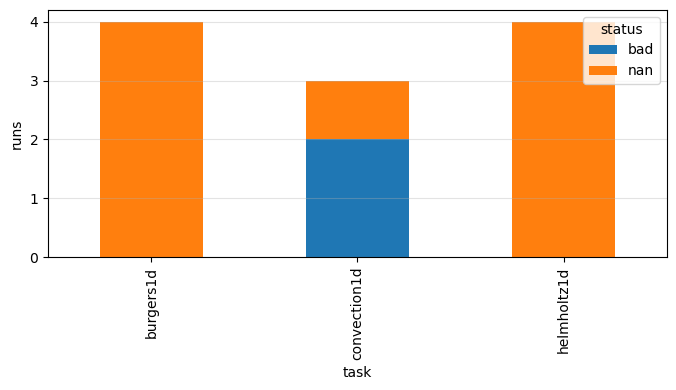

In [25]:
fp = fp16.copy()
if len(fp) > 0:
    fp['status'] = 'ok'
    fp.loc[fp['best_l2_error'].isna(), 'status'] = 'nan'
    fp.loc[fp['best_l2_error'] > 0.2, 'status'] = 'bad'
    cnt = fp.groupby(['task_name', 'status']).size().reset_index(name='count')
    cnt.to_csv(table_dir / 'fp16_status.csv', index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    pivot = cnt.pivot_table(index='task_name', columns='status', values='count', fill_value=0)
    pivot.plot(kind='bar', stacked=True, ax=ax)
    ax.set_ylabel('runs')
    ax.set_xlabel('task')
    ax.grid(True, axis='y', alpha=0.35)
    fig.tight_layout()
    fig.savefig(fig_dir / 'fp16_status.png', dpi=180)
    plt.show()
else:
    print('no fp16 runs')

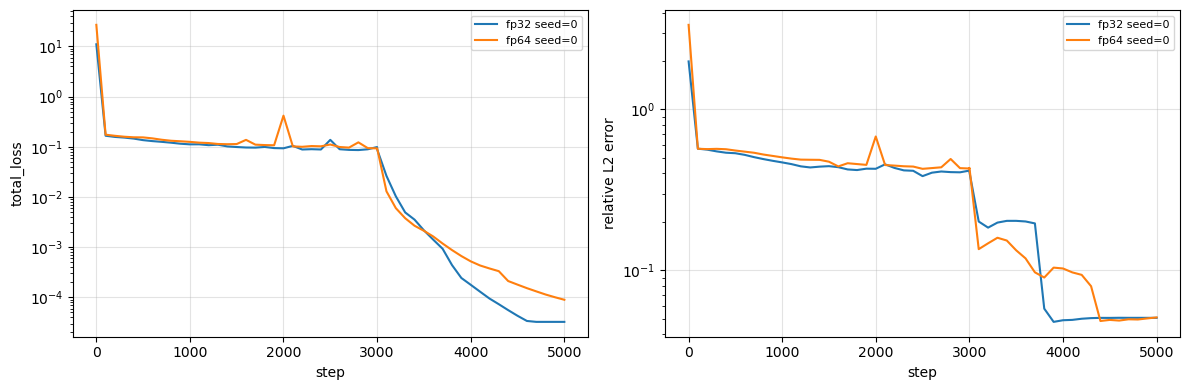

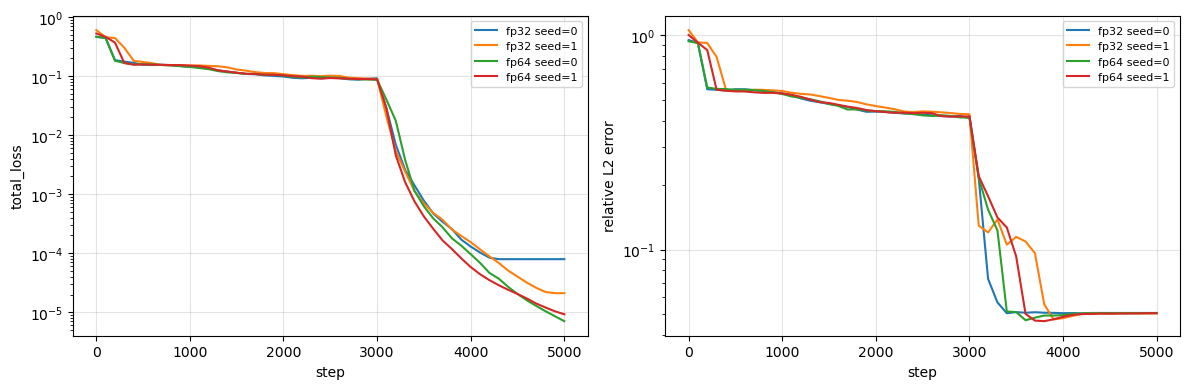

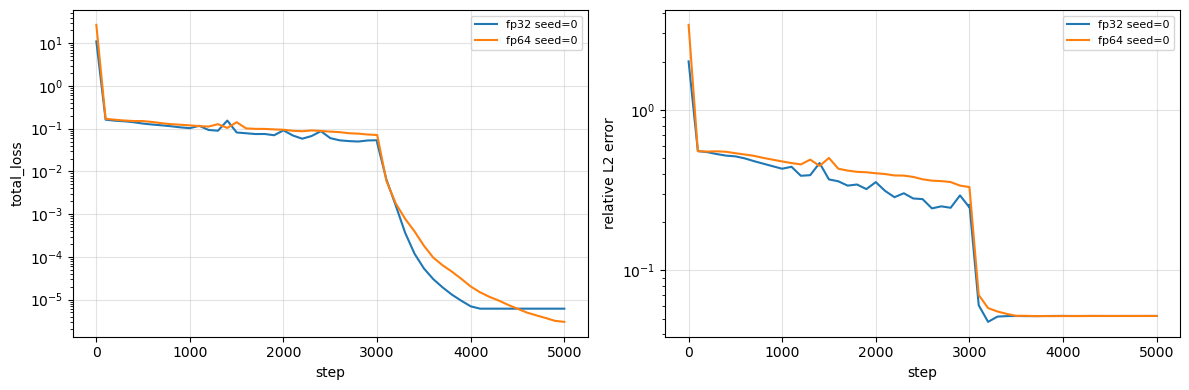

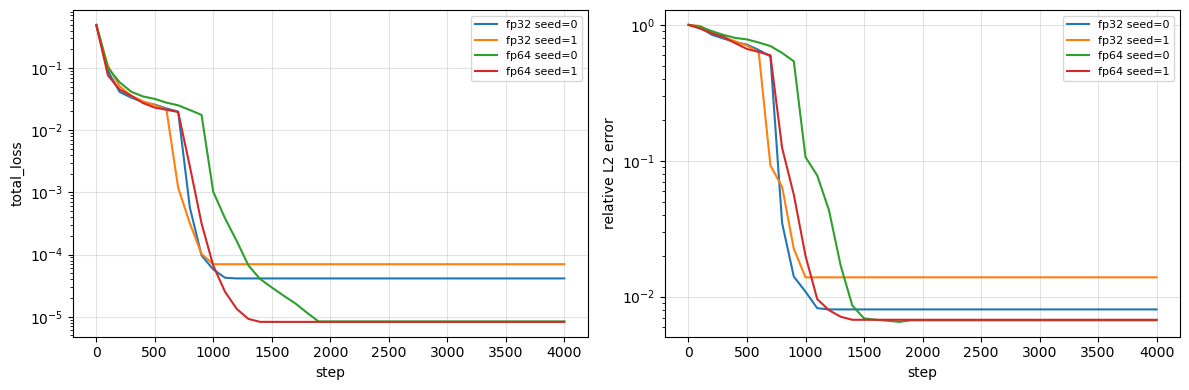

[PosixPath('../../final/final 2/results_outputs/figures/curves_selected_1.png'),
 PosixPath('../../final/final 2/results_outputs/figures/curves_selected_2.png'),
 PosixPath('../../final/final 2/results_outputs/figures/curves_selected_3.png'),
 PosixPath('../../final/final 2/results_outputs/figures/curves_selected_4.png')]

In [26]:
def fix_log_dir(x):
    if pd.isna(x):
        return None
    s = str(x)
    cand = [root / s / 'metrics.csv']
    if s.startswith('/kaggle/working/'):
        rel = s.replace('/kaggle/working/', '')
        cand.append(root / rel / 'metrics.csv')
        parts = rel.split('/', 1)
        if len(parts) == 2:
            cand.append(root / parts[0] / rel / 'metrics.csv')
    if s.startswith('final/runs/'):
        cand.append(base_dir / 'runs' / s.replace('final/runs/', '') / 'metrics.csv')
    for p in cand:
        if p.exists():
            return p
    return None

def save_curves(row, name):
    cur = main[
        (main['source'] == row.source)
        & (main['task_name'] == row.task_name)
        & (main['variant'] == row.variant)
        & (main['case_name'] == row.case_name)
        & (main['case_value'] == row.case_value)
    ].copy()
    if len(cur) == 0 or 'log_dir' not in cur.columns:
        return None
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    n = 0
    for r0 in cur.sort_values(['dtype', 'seed']).itertuples():
        p = fix_log_dir(r0.log_dir)
        if p is None:
            continue
        h0 = pd.read_csv(p)
        label = f'{r0.dtype} seed={r0.seed}'
        ax[0].plot(h0['step'], h0['total_loss'], label=label)
        ax[1].plot(h0['step'], h0['l2_error'], label=label)
        n += 1
    if n == 0:
        plt.close(fig)
        return None
    ax[0].set_yscale('log')
    ax[1].set_yscale('log')
    ax[0].set_xlabel('step')
    ax[1].set_xlabel('step')
    ax[0].set_ylabel('total_loss')
    ax[1].set_ylabel('relative L2 error')
    ax[0].grid(True, alpha=0.35)
    ax[1].grid(True, alpha=0.35)
    ax[0].legend(fontsize=8)
    ax[1].legend(fontsize=8)
    fig.tight_layout()
    p = fig_dir / name
    fig.savefig(p, dpi=180)
    plt.show()
    return p

curve_rows = clear.head(6).copy()
curve_files = []
for i, row in enumerate(curve_rows.itertuples(), 1):
    name = f'curves_selected_{i}.png'
    p = save_curves(row, name)
    if p is not None:
        curve_files.append(p)

curve_files

In [27]:
print('tables')
for p in sorted(table_dir.glob('*.csv')):
    print(p.name)

print('figures')
for p in sorted(fig_dir.glob('*.png')):
    print(p.name)

tables
all_loaded_runs.csv
control_results.csv
excluded_fp32_not_learned.csv
fp16_results.csv
fp16_status.csv
fp64_ratio_all.csv
grouped_results.csv
selected_comparisons.csv
selected_experiment_plan.csv
figures
control_cases_scatter.png
curves_selected_1.png
curves_selected_2.png
curves_selected_3.png
curves_selected_4.png
curves_selected_5.png
curves_selected_6.png
final_results_cases.png
fp16_status.png
fp64_ratio_selected.png
helmholtz_resample_sweep.png
selected_best_l2.png


fp64_ratio_selected.png


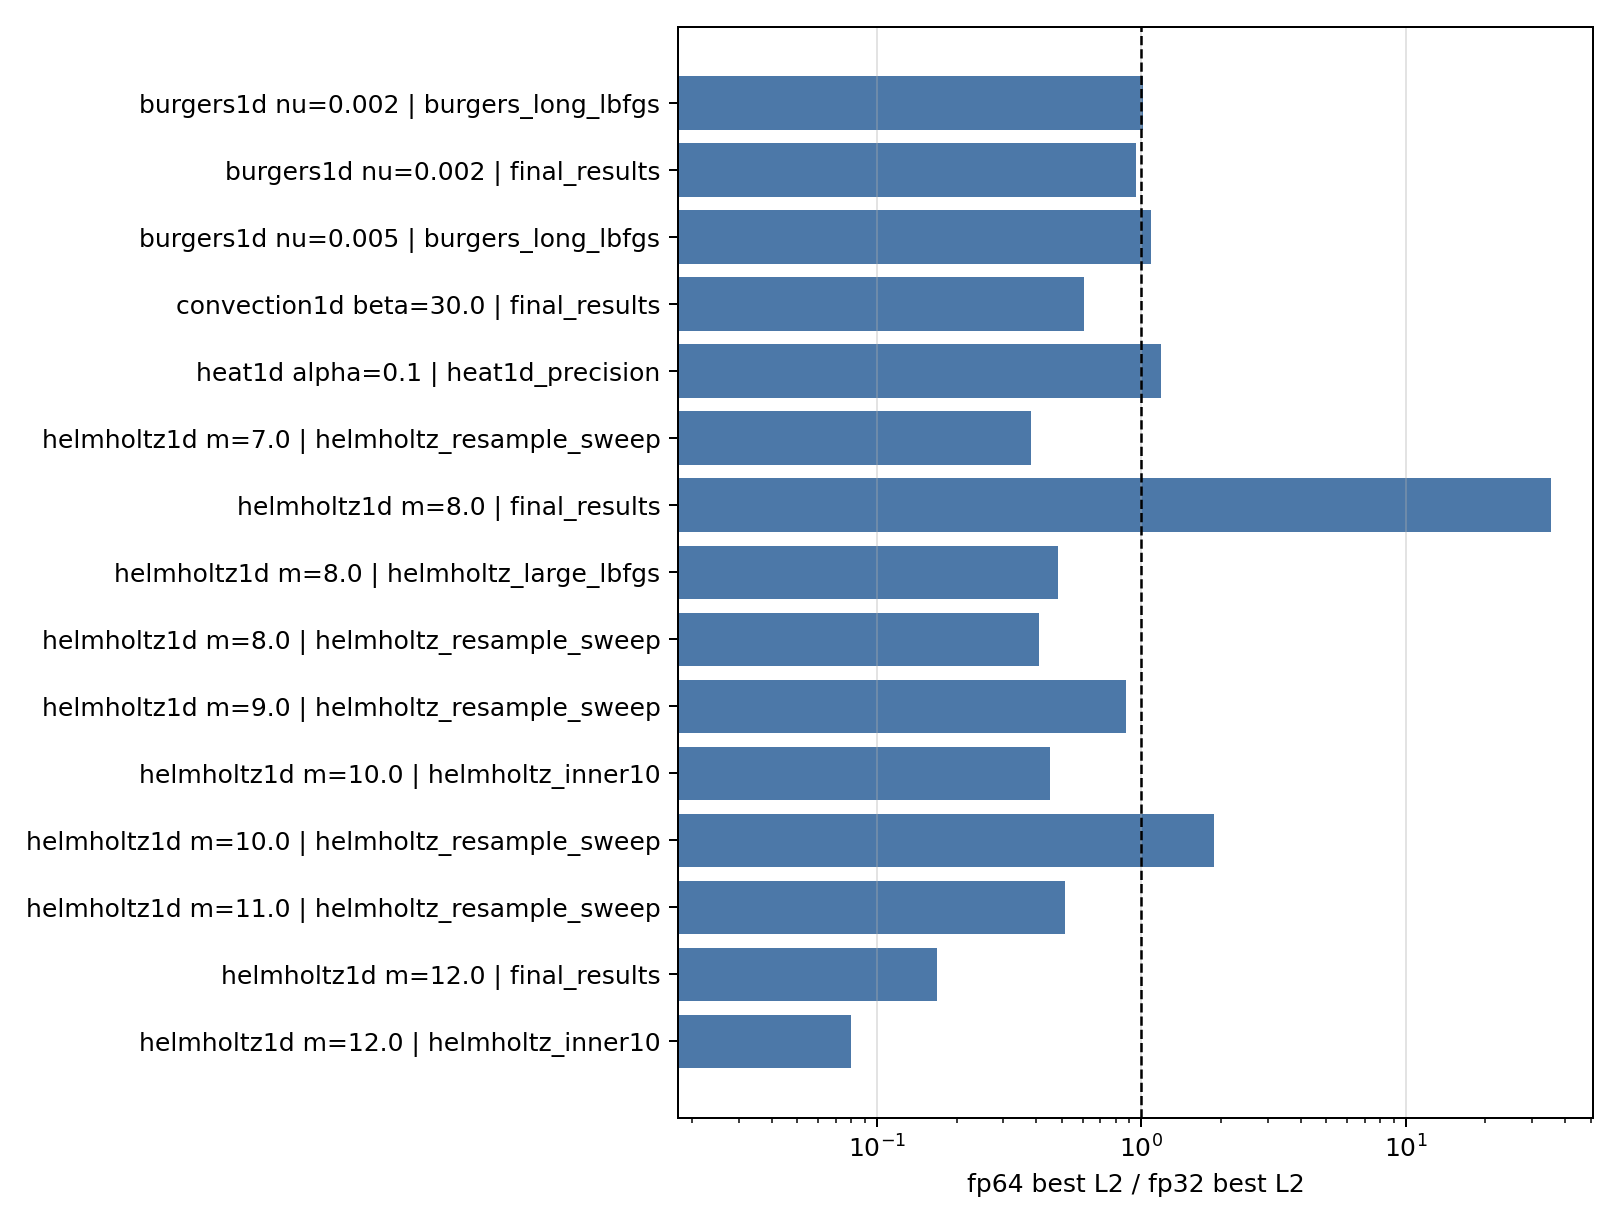

selected_best_l2.png


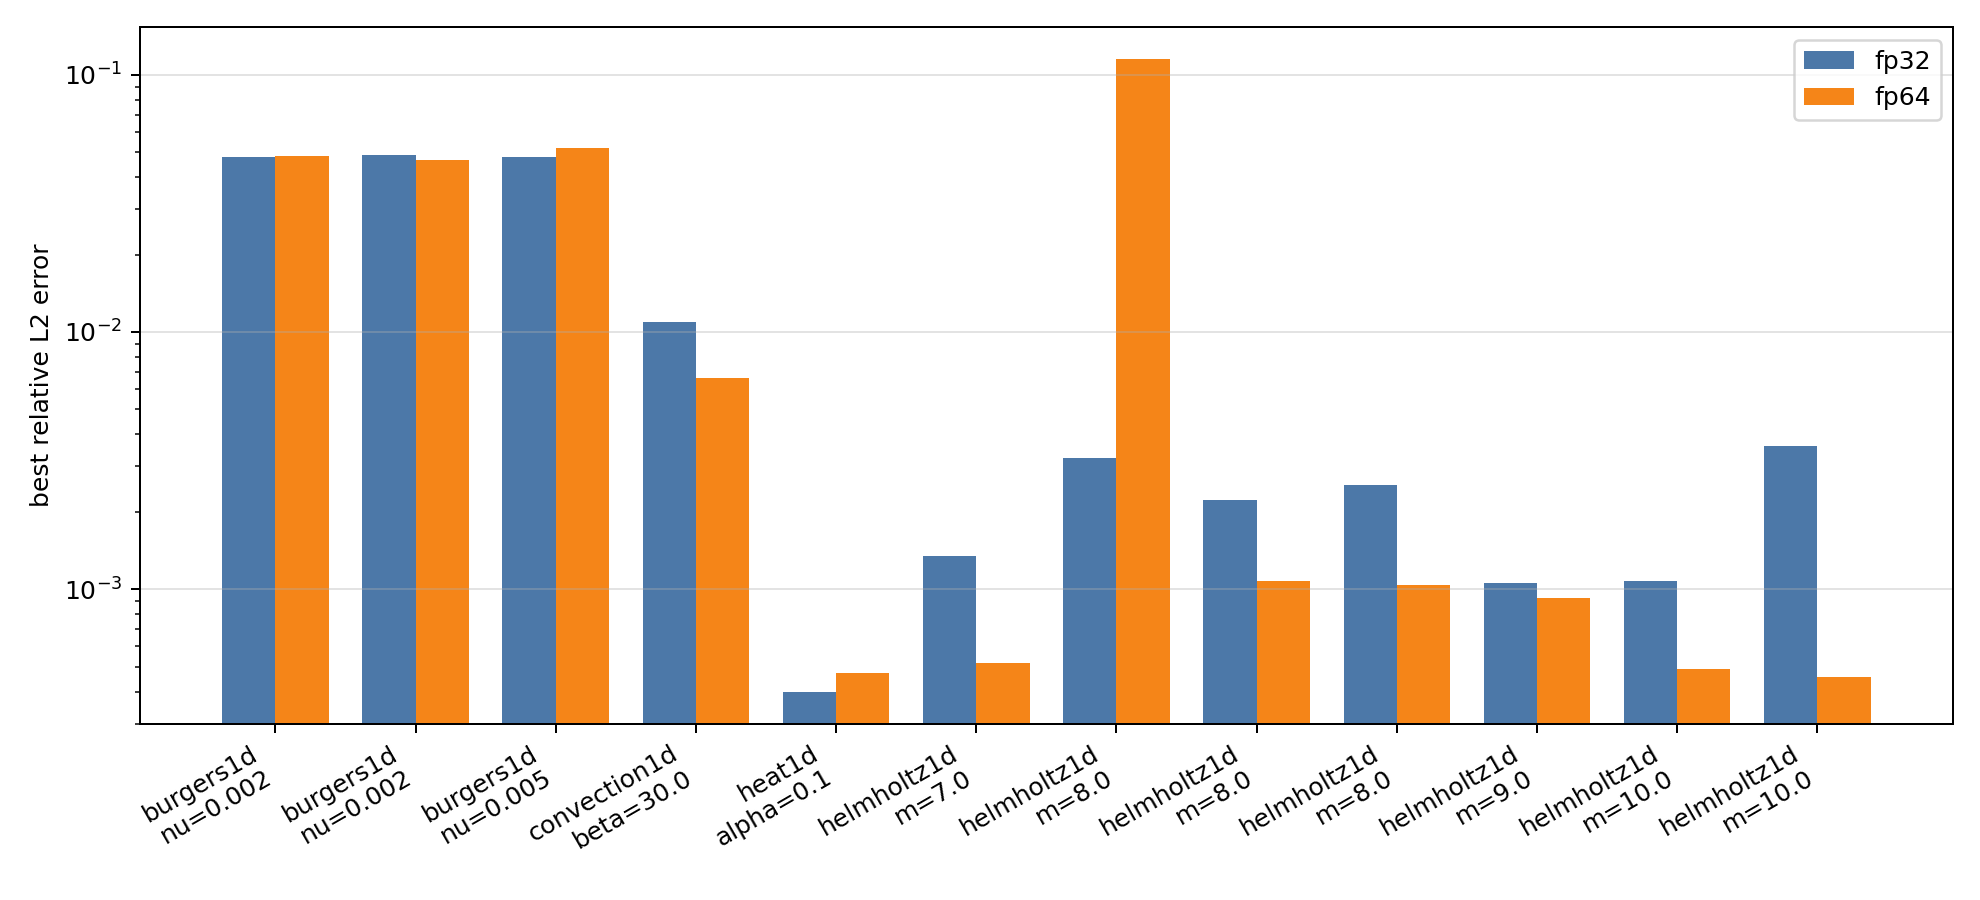

helmholtz_resample_sweep.png


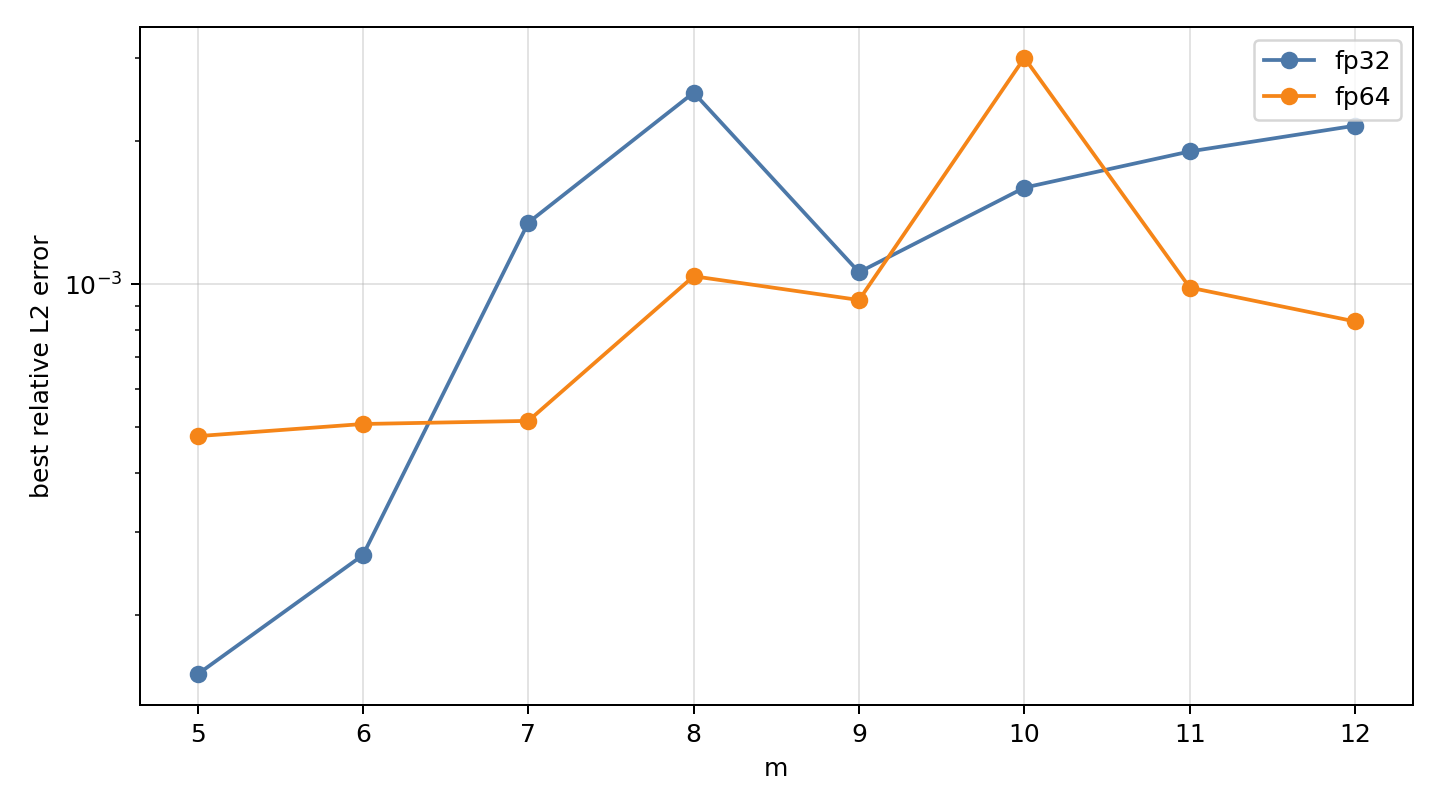

final_results_cases.png


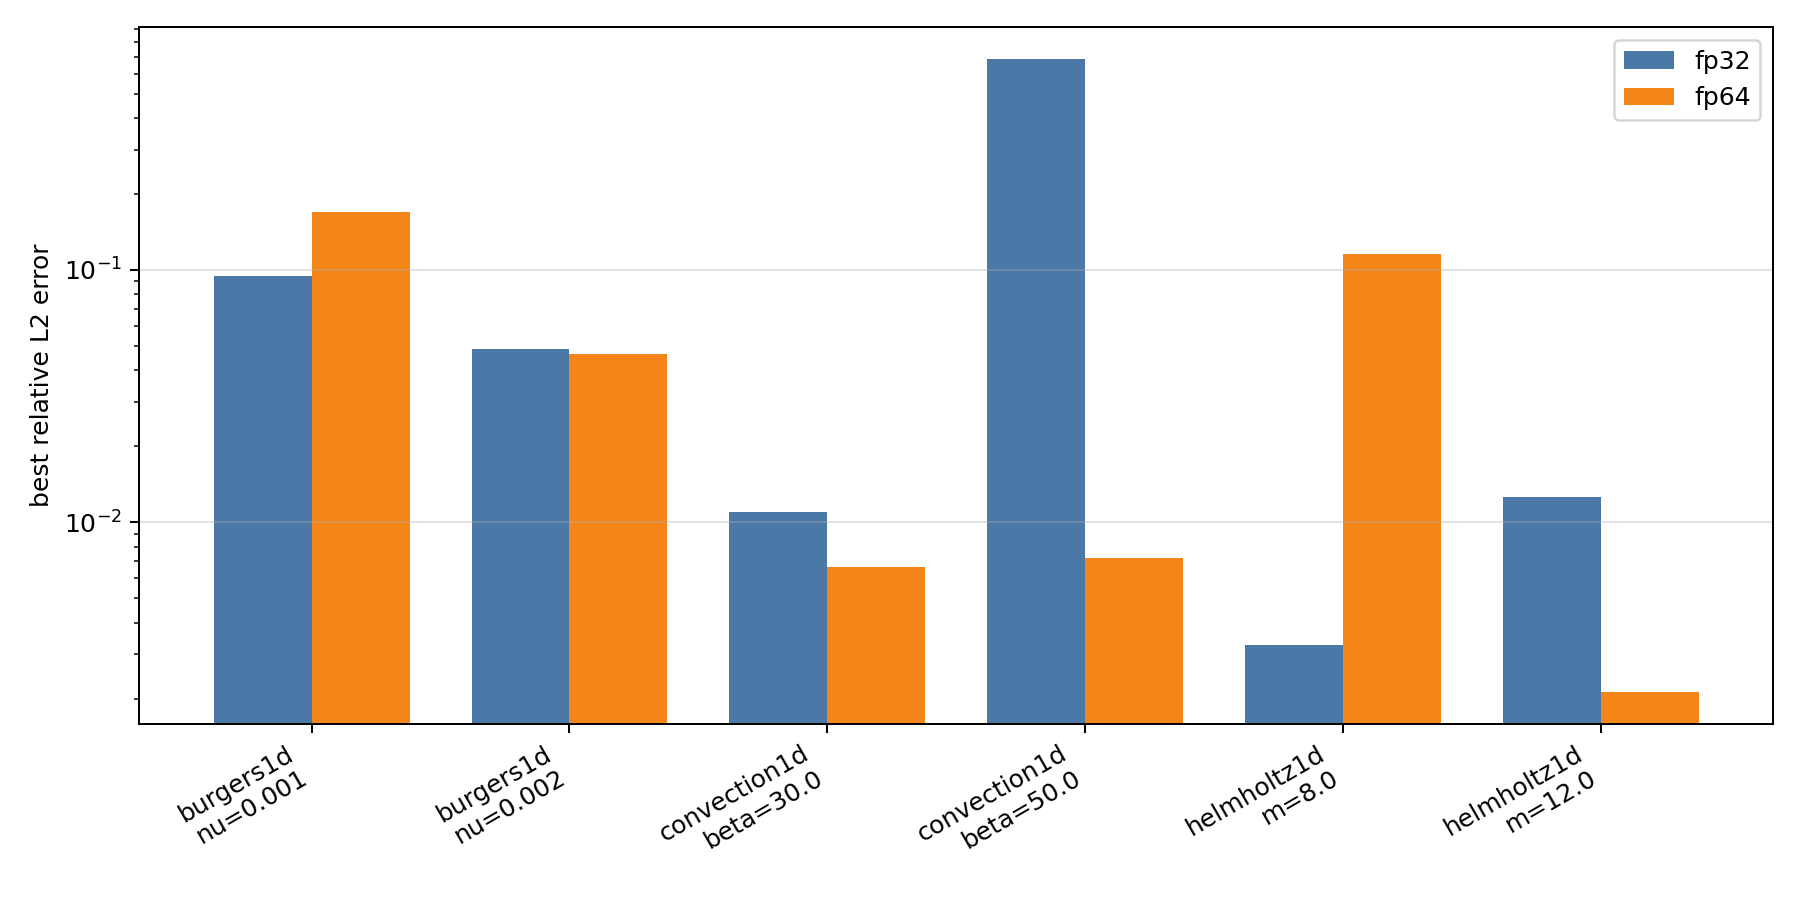

control_cases_scatter.png


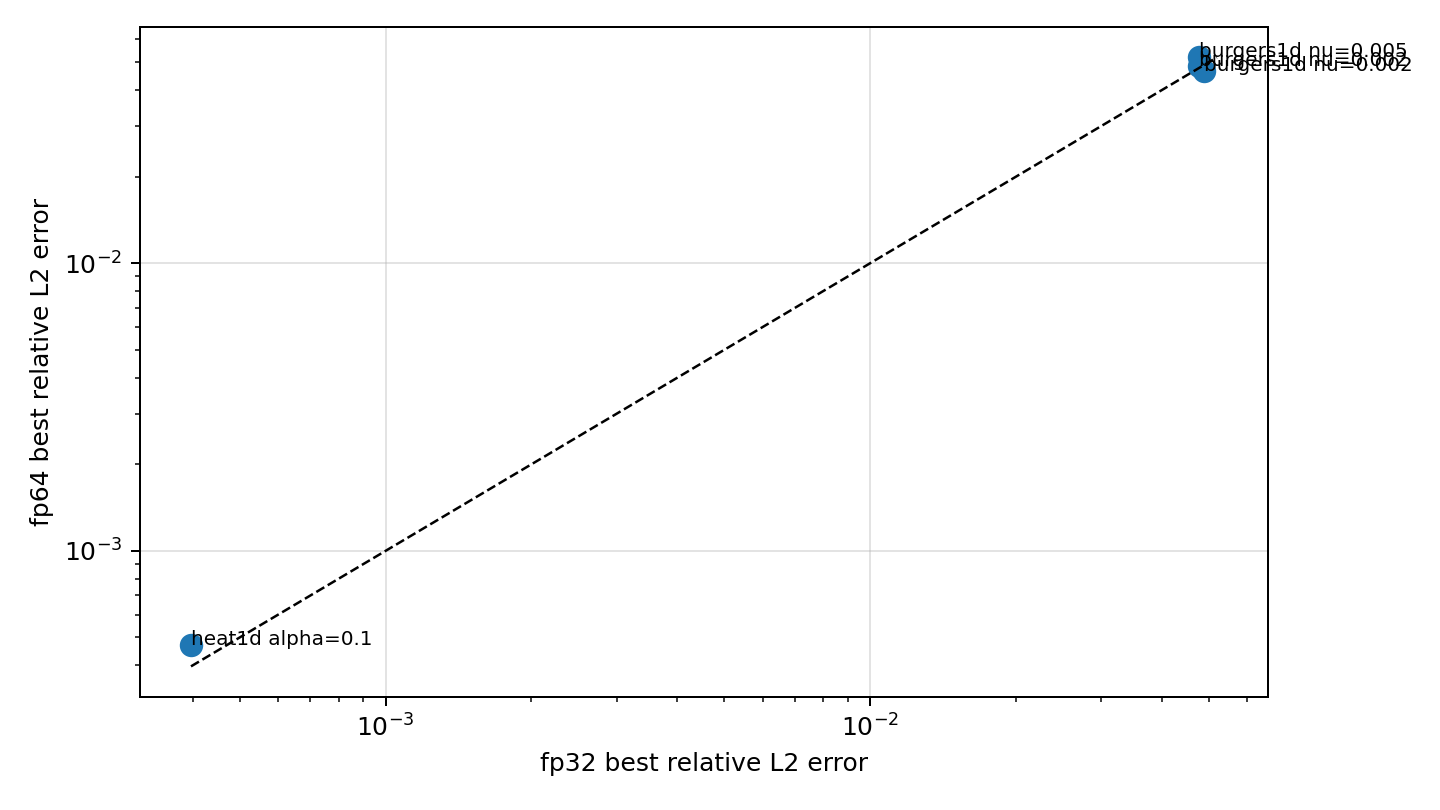

fp16_status.png


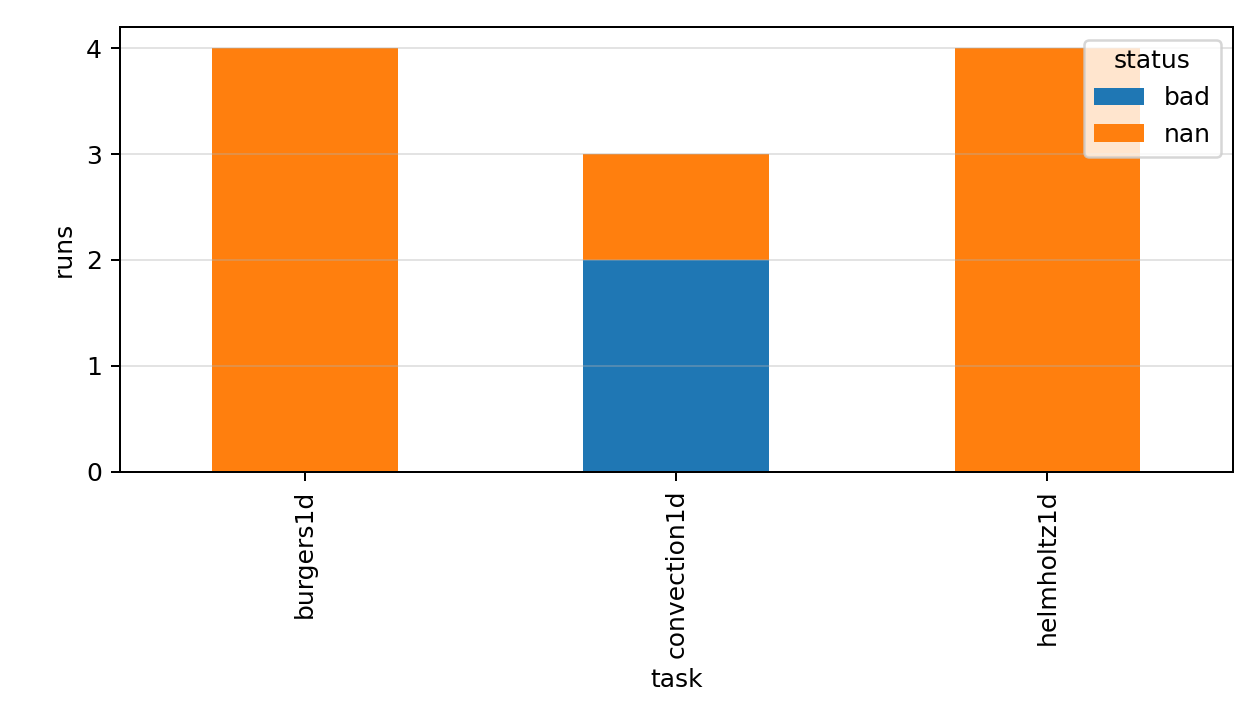

In [28]:
for name in [
    'fp64_ratio_selected.png',
    'selected_best_l2.png',
    'helmholtz_resample_sweep.png',
    'final_results_cases.png',
    'control_cases_scatter.png',
    'fp16_status.png',
]:
    p = fig_dir / name
    if p.exists():
        print(name)
        display(Image(filename=str(p)))